# ECDA Preschool Demand Forecasting at Subzone Level

Addresses the ECDA planning problem:

> Forecast subzone-level demand for preschool services, especially childcare programmes for children aged **18 months to 6 years**, over the next 5 years. Identify where ECDA should prioritise building or relocating preschools. Assume each preschool can accommodate up to **100 children**.

Covers:
1. Data cleaning and integration
2. Preschool-age demand definition
3. Forecasting with Linear Regression, Prophet, and XGBoost
4. Backtesting and model selection
5. Preschool supply estimation using ECDA centre listing
6. Treatment of `NA` service models
7. Supply-demand gap analysis
8. Priority ranking by subzone
9. Streamlit tool prototype and deployment plan

## Key Modelling Decisions

### Demand definition

The population data is by single year of age, so childcare demand for children aged **18 months to 6 years** is approximated as:

```text
Demand = 0.5 x Age 1 + Age 2 + Age 3 + Age 4 + Age 5 + Age 6
```


### NA service model assumption

Centres with service model `na` are ECDA-listed centres with missing/unknown service type. They are not silently dropped.

Base-case assumption:

```text
NA centres are included as unknown preschool supply, with capacity = 100.
```

Sensitivity scenarios are also created:
- `strict_childcare`: CC, EYC, EYC-DS
- `base_preschool`: CC, KN, EYC, EYC-DS, NA
- `broad_all`: CC, KN, EYC, EYC-DS, DS, NA

## 0. Setup

In [1]:
import os
import re
import math
import time
import warnings
from pathlib import Path

import numpy as np
import pandas as pd

warnings.filterwarnings("ignore")

from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error

try:
    from prophet import Prophet
    PROPHET_AVAILABLE = True
except Exception as e:
    PROPHET_AVAILABLE = False
    print("Prophet is not available. Install with: pip install prophet")
    print("Reason:", e)

try:
    from xgboost import XGBRegressor
    XGBOOST_AVAILABLE = True
except Exception as e:
    XGBOOST_AVAILABLE = False
    print("XGBoost is not available. Install with: pip install xgboost")
    print("Reason:", e)

try:
    import geopandas as gpd
    from shapely.geometry import Point
    GEOSPATIAL_AVAILABLE = True
except Exception as e:
    GEOSPATIAL_AVAILABLE = False
    print("GeoPandas/Shapely is not available. Install with: pip install geopandas shapely")
    print("Reason:", e)

FILE_DIR = Path("data")  # data folder next to this notebook
OUTPUT_DIR = Path("outputs")
OUTPUT_DIR.mkdir(exist_ok=True)

POP_2000_2020_XLSX = FILE_DIR / "respopagesex2000to2020e.xlsx"
POP_2021_CSV = FILE_DIR / "respopagesex2021.csv"
POP_2022_CSV = FILE_DIR / "respopagesex2022.csv"
POP_2023_CSV = FILE_DIR / "respopagesex2023.csv"
POP_2024_CSV = FILE_DIR / "respopagesex2024.csv"
POP_2025_CSV = FILE_DIR / "respopagesex2025.csv"

BTO_CSV = FILE_DIR / "btomapping.csv"
CENTRES_CSV = FILE_DIR / "ListingofCentres.csv"
BIRTHS_CSV = FILE_DIR / "BirthsAndFertilityRatesAnnual.csv"
SUBZONE_GEOJSON = FILE_DIR / "MasterPlan2019SubzoneBoundaryNoSeaGEOJSON.geojson"

input_files = [
    POP_2000_2020_XLSX, POP_2021_CSV, POP_2022_CSV, POP_2023_CSV, POP_2024_CSV, POP_2025_CSV,
    BTO_CSV, CENTRES_CSV, BIRTHS_CSV, SUBZONE_GEOJSON
]

for p in input_files:
    print(f"{p.name}: {p.exists()}")

Importing plotly failed. Interactive plots will not work.


respopagesex2000to2020e.xlsx: True
respopagesex2021.csv: True
respopagesex2022.csv: True
respopagesex2023.csv: True
respopagesex2024.csv: True
respopagesex2025.csv: True
btomapping.csv: True
ListingofCentres.csv: True
BirthsAndFertilityRatesAnnual.csv: True
MasterPlan2019SubzoneBoundaryNoSeaGEOJSON.geojson: True


## 1. Helper Functions

In [2]:
def clean_name(x):
    """Standardise planning area and subzone names for joining."""
    if pd.isna(x):
        return np.nan
    x = str(x).strip().upper()
    x = x.replace("-", " ")
    x = re.sub(r"[^A-Z0-9 ]", "", x)
    x = re.sub(r"\s+", " ", x).strip()
    return x

def safe_read_csv(path):
    """Read CSV with fallback encoding."""
    try:
        return pd.read_csv(path)
    except UnicodeDecodeError:
        return pd.read_csv(path, encoding="latin1")

def to_number(x):
    """Convert SingStat values to numeric."""
    if pd.isna(x):
        return np.nan
    x = str(x).replace(",", "").strip()
    if x.lower() in ["na", "nan", "-", "", "total"]:
        return np.nan
    return pd.to_numeric(x, errors="coerce")

def rmse(y_true, y_pred):
    return math.sqrt(mean_squared_error(y_true, y_pred))

## 2. Load Population Data

The population Excel file has these sheets:

```text
2000
2001-2010
2011-2019
2020
```

The real header row is row index 2, so we parse with `header=2`.

In [3]:
def parse_population_excel_2000_2020(path):
    all_parts = []
    xls = pd.ExcelFile(path)
    print("Excel sheets:", xls.sheet_names)

    for sheet in xls.sheet_names:
        df = pd.read_excel(path, sheet_name=sheet, header=2)
        df = df.dropna(how="all").dropna(axis=1, how="all")
        df.columns = [str(c).strip() for c in df.columns]

        id_cols = df.columns[:4].tolist()
        year_cols = [c for c in df.columns[4:] if re.search(r"(20\d{2}|19\d{2})", str(c))]

        if len(id_cols) < 4 or len(year_cols) == 0:
            print("Problem sheet:", sheet)
            print(df.columns.tolist())
            raise ValueError("Could not identify population Excel columns.")

        tmp = df[id_cols + year_cols].copy()
        tmp.columns = ["planning_area", "subzone", "age", "sex"] + [str(c).strip() for c in year_cols]

        tmp_long = tmp.melt(
            id_vars=["planning_area", "subzone", "age", "sex"],
            value_vars=[str(c).strip() for c in year_cols],
            var_name="year",
            value_name="resident_population"
        )

        tmp_long["year"] = tmp_long["year"].astype(str).str.extract(r"(20\d{2}|19\d{2})")[0]
        all_parts.append(tmp_long)

    return pd.concat(all_parts, ignore_index=True)

def parse_population_annual_csv(path):
    df = safe_read_csv(path)
    required = ["PA", "SZ", "Age", "Sex", "Pop", "Time"]
    missing = [c for c in required if c not in df.columns]
    if missing:
        raise ValueError(f"{path.name} missing columns: {missing}")

    out = df[["Time", "PA", "SZ", "Age", "Sex", "Pop"]].copy()
    out.columns = ["year", "planning_area", "subzone", "age", "sex", "resident_population"]
    return out

pop_parts = [parse_population_excel_2000_2020(POP_2000_2020_XLSX)]

for p in [POP_2021_CSV, POP_2022_CSV, POP_2023_CSV, POP_2024_CSV, POP_2025_CSV]:
    pop_parts.append(parse_population_annual_csv(p))

pop_raw = pd.concat(pop_parts, ignore_index=True)

pop_long = pop_raw.copy()
pop_long["year"] = pd.to_numeric(pop_long["year"], errors="coerce")
pop_long["planning_area_clean"] = pop_long["planning_area"].apply(clean_name)
pop_long["subzone_clean"] = pop_long["subzone"].apply(clean_name)
pop_long["age_num"] = pd.to_numeric(pop_long["age"].astype(str).str.extract(r"(\d+)")[0], errors="coerce")
pop_long["sex_clean"] = pop_long["sex"].astype(str).str.strip().str.upper()
pop_long["resident_population"] = pop_long["resident_population"].apply(to_number).fillna(0)

pop_long = pop_long.dropna(subset=["year", "planning_area_clean", "subzone_clean", "age_num"])
pop_long["year"] = pop_long["year"].astype(int)
pop_long["age_num"] = pop_long["age_num"].astype(int)

pop_long = pop_long[
    ~pop_long["planning_area_clean"].isin(["TOTAL", ""])
    & ~pop_long["subzone_clean"].isin(["TOTAL", ""])
    & ~pop_long["age"].astype(str).str.upper().isin(["TOTAL"])
    & pop_long["sex_clean"].isin(["MALES", "FEMALES"])
].copy()

print("Population long shape:", pop_long.shape)
print("Year range:", pop_long["year"].min(), "-", pop_long["year"].max())
print("Unique subzones:", pop_long[["planning_area_clean", "subzone_clean"]].drop_duplicates().shape[0])
display(pop_long.head())

Excel sheets: ['2000', '2001-2010', '2011-2019', '2020']


Population long shape: (1514422, 10)
Year range: 2000 - 2025


Unique subzones: 412


,planning_area,subzone,age,sex,year,resident_population,planning_area_clean,subzone_clean,age_num,sex_clean
556,Ang Mo Kio,Cheng San,0,Males,2000,140.0,ANG MO KIO,CHENG SAN,0,MALES
557,Ang Mo Kio,Cheng San,0,Females,2000,130.0,ANG MO KIO,CHENG SAN,0,FEMALES
559,Ang Mo Kio,Cheng San,1,Males,2000,180.0,ANG MO KIO,CHENG SAN,1,MALES
560,Ang Mo Kio,Cheng San,1,Females,2000,140.0,ANG MO KIO,CHENG SAN,1,FEMALES
562,Ang Mo Kio,Cheng San,2,Males,2000,160.0,ANG MO KIO,CHENG SAN,2,MALES


## 3. Construct Preschool-age Demand

In [4]:
eligible = pop_long[pop_long["age_num"].between(1, 6)].copy()
eligible["age_weight"] = np.where(eligible["age_num"] == 1, 0.5, 1.0)
eligible["weighted_population"] = eligible["resident_population"] * eligible["age_weight"]

demand_hist = (
    eligible.groupby(["year", "planning_area_clean", "subzone_clean"], as_index=False)
            ["weighted_population"].sum()
            .rename(columns={"weighted_population": "children_18m_to_6"})
)

demand_hist["children_18m_to_6"] = demand_hist["children_18m_to_6"].fillna(0)

print("Demand history shape (before recency filter):", demand_hist.shape)

# The population panel is stitched together from several census editions
# (2000-2020 Excel sheets, then separate 2021-2025 CSVs). Singapore's subzone
# boundaries get revised between editions, so some subzone names in the older
# sheets (e.g. pre-2011) do not exist in the most recent data at all -- they
# were renamed, merged, or dissolved as new towns were built out. If we forecast
# those stale keys anyway, the models just extrapolate from a short, decade-old
# window and can produce large, meaningless "demand" for a subzone that has not
# officially existed for over 10 years. We only keep subzones that still appear
# in the latest available census year, since those are the only ones ECDA can
# actually act on.
LATEST_CENSUS_YEAR = int(pop_long["year"].max())
current_subzones = set(
    map(tuple, pop_long.loc[pop_long["year"] == LATEST_CENSUS_YEAR, ["planning_area_clean", "subzone_clean"]].drop_duplicates().values)
)

demand_hist["subzone_key_tuple"] = list(zip(demand_hist["planning_area_clean"], demand_hist["subzone_clean"]))
n_before = demand_hist[["planning_area_clean", "subzone_clean"]].drop_duplicates().shape[0]
demand_hist = demand_hist[demand_hist["subzone_key_tuple"].isin(current_subzones)].drop(columns=["subzone_key_tuple"]).copy()
n_after = demand_hist[["planning_area_clean", "subzone_clean"]].drop_duplicates().shape[0]

print(f"Dropped {n_before - n_after} stale/deprecated subzones not present in {LATEST_CENSUS_YEAR} census data.")
print("Demand history shape (after recency filter):", demand_hist.shape)
display(demand_hist.head())

display(
    demand_hist.groupby("year")["children_18m_to_6"]
               .sum()
               .reset_index()
               .tail(10)
)

Demand history shape (before recency filter): (8321, 4)
Dropped 80 stale/deprecated subzones not present in 2025 census data.
Demand history shape (after recency filter): (7741, 4)


,year,planning_area_clean,subzone_clean,children_18m_to_6
0,2000,ANG MO KIO,CHENG SAN,2020.0
1,2000,ANG MO KIO,CHONG BOON,2030.0
2,2000,ANG MO KIO,KEBUN BAHRU,1810.0
4,2000,ANG MO KIO,SEMBAWANG HILLS,415.0
5,2000,ANG MO KIO,SHANGRI LA,1455.0


,year,children_18m_to_6
16,2016,210790.0
17,2017,212720.0
18,2018,215170.0
19,2019,214695.0
20,2020,211935.0
21,2021,209390.0
22,2022,209590.0
23,2023,206860.0
24,2024,203750.0
25,2025,198760.0


## 4. Load BTO and Birth/Fertility Data

In [5]:
bto = safe_read_csv(BTO_CSV)
print("BTO shape:", bto.shape)
display(bto.head())

required_bto_cols = [
    "Planning area", "Subzone", "Estimated completion year", "Total number of units"
]
missing_bto = [c for c in required_bto_cols if c not in bto.columns]
if missing_bto:
    raise ValueError(f"BTO missing columns: {missing_bto}")

bto_clean = bto.copy()
bto_clean["planning_area_clean"] = bto_clean["Planning area"].apply(clean_name)
bto_clean["subzone_clean"] = bto_clean["Subzone"].apply(clean_name)
bto_clean["completion_year"] = pd.to_numeric(bto_clean["Estimated completion year"], errors="coerce")
bto_clean["bto_units"] = pd.to_numeric(bto_clean["Total number of units"], errors="coerce").fillna(0)

bto_agg = (
    bto_clean.dropna(subset=["completion_year"])
             .groupby(["planning_area_clean", "subzone_clean", "completion_year"], as_index=False)
             ["bto_units"].sum()
)
bto_agg["completion_year"] = bto_agg["completion_year"].astype(int)

display(bto_agg.head())

BTO shape: (223, 6)


,BTO project name,Region,Planning area,Subzone,Estimated completion year,Total number of units
0,Toa Payoh Apex,Central Region,Toa Payoh,Boon Teck,2018,557
1,Fengshan GreenVille,East Region,Bedok,Bedok North,2018,1058
2,Sun Breeze,North Region,Sembawang,Sembawang Central,2018,700
3,Sun Natura,North Region,Sembawang,Sembawang Central,2018,848
4,Marsiling Greenview,North Region,Woodlands,Woodlands West,2018,1304


,planning_area_clean,subzone_clean,completion_year,bto_units
0,ANG MO KIO,ANG MO KIO TOWN CENTRE,2028,896
1,ANG MO KIO,CHENG SAN,2018,712
2,ANG MO KIO,SHANGRI LA,2020,590
3,ANG MO KIO,SHANGRI LA,2025,380
4,ANG MO KIO,YIO CHU KANG WEST,2023,454


In [6]:
births = safe_read_csv(BIRTHS_CSV)
print("Birth/fertility shape:", births.shape)
display(births.head())

year_cols = [c for c in births.columns if re.fullmatch(r"(20\d{2}|19\d{2})", str(c))]
if "DataSeries" not in births.columns or len(year_cols) == 0:
    raise ValueError("Birth/fertility file format is not as expected.")

feature_tables = []

for _, row in births.iterrows():
    raw_label = str(row["DataSeries"])
    label = clean_name(raw_label)
    if pd.isna(label):
        continue

    keep = (
        "TOTAL FERTILITY RATE" in label
        or "25 29" in label
        or "30 34" in label
        or "35 39" in label
    )

    if not keep:
        continue

    col_name = "birth_" + label.lower().replace(" ", "_")
    tmp = pd.DataFrame({
        "year": [int(c) for c in year_cols],
        col_name: [to_number(row[c]) for c in year_cols]
    })
    feature_tables.append(tmp)

if len(feature_tables) == 0:
    birth_features = pd.DataFrame({"year": sorted(demand_hist["year"].unique())})
else:
    birth_features = feature_tables[0]
    for t in feature_tables[1:]:
        birth_features = birth_features.merge(t, on="year", how="outer")
    birth_features = birth_features.sort_values("year")

birth_features = birth_features[birth_features["year"].between(demand_hist["year"].min(), demand_hist["year"].max())].copy()
feature_cols_birth = [c for c in birth_features.columns if c != "year"]
birth_features[feature_cols_birth] = birth_features[feature_cols_birth].ffill().bfill()

print("Birth features used:", feature_cols_birth)
display(birth_features.tail())

Birth/fertility shape: (17, 67)


,DataSeries,2025,2024,2023,2022,2021,2020,2019,2018,2017,...,1969,1968,1967,1966,1965,1964,1963,1962,1961,1960
0,Total Fertility Rate (TFR),0.87,0.97,0.97,1.04,1.12,1.1,1.14,1.14,1.16,...,3.22,3.53,3.91,4.46,4.66,4.97,5.16,5.21,5.41,5.76
1,15 - 19 Years,1.30,2.30,2.20,2.10,2.20,2.3,2.50,2.50,2.60,...,27.1,30.9,35.8,33,35.9,38.3,45.7,52,63.4,69.6
2,20 - 24 Years,8.70,9.80,10.60,11.20,11.70,12.7,12.70,14.40,15.10,...,150.1,165.8,195.8,218.5,227.1,240,249,245.5,241.1,250.5
3,25 - 29 Years,38.10,42.60,43.70,48.80,53.40,54.6,59.40,60.60,62.20,...,227.8,236.6,244.7,261.2,259.5,277.6,287.2,291.7,304.9,323.9
4,30 - 34 Years,69.70,79.30,78.70,86.70,92.90,90.8,92.40,92.90,93.30,...,134.3,152,166.7,202,216.2,226.7,228.7,231.5,238.4,259.7


Birth features used: ['birth_total_fertility_rate_tfr', 'birth_25_29_years', 'birth_30_34_years', 'birth_35_39_years']


,year,birth_total_fertility_rate_tfr,birth_25_29_years,birth_30_34_years,birth_35_39_years
61,2021,1.12,53.4,92.9,53.6
62,2022,1.04,48.8,86.7,49.4
63,2023,0.97,43.7,78.7,47.9
64,2024,0.97,42.6,79.3,50.0
65,2025,0.87,38.1,69.7,46.0


## 5. Build BTO Effect Features

In [7]:
BTO_CHILD_FACTOR = 0.12
BTO_LAGS = [1, 2, 3]

bto_effect_rows = []

for _, row in bto_agg.iterrows():
    for lag in BTO_LAGS:
        bto_effect_rows.append({
            "planning_area_clean": row["planning_area_clean"],
            "subzone_clean": row["subzone_clean"],
            "year": int(row["completion_year"] + lag),
            "bto_units_effective": row["bto_units"] / len(BTO_LAGS),
            "bto_demand_addition": row["bto_units"] * BTO_CHILD_FACTOR / len(BTO_LAGS)
        })

bto_effect = pd.DataFrame(bto_effect_rows)

if len(bto_effect) > 0:
    bto_effect = (
        bto_effect.groupby(["planning_area_clean", "subzone_clean", "year"], as_index=False)
                  .agg({
                      "bto_units_effective": "sum",
                      "bto_demand_addition": "sum"
                  })
    )
else:
    bto_effect = pd.DataFrame(columns=[
        "planning_area_clean", "subzone_clean", "year",
        "bto_units_effective", "bto_demand_addition"
    ])

display(bto_effect.head())

,planning_area_clean,subzone_clean,year,bto_units_effective,bto_demand_addition
0,ANG MO KIO,ANG MO KIO TOWN CENTRE,2029,298.666667,35.84
1,ANG MO KIO,ANG MO KIO TOWN CENTRE,2030,298.666667,35.84
2,ANG MO KIO,ANG MO KIO TOWN CENTRE,2031,298.666667,35.84
3,ANG MO KIO,CHENG SAN,2019,237.333333,28.48
4,ANG MO KIO,CHENG SAN,2020,237.333333,28.48


## 6. Build Modelling Dataset

In [8]:
model_df = demand_hist.copy()

model_df = model_df.merge(
    bto_effect,
    on=["planning_area_clean", "subzone_clean", "year"],
    how="left"
)
model_df["bto_units_effective"] = model_df["bto_units_effective"].fillna(0)
model_df["bto_demand_addition"] = model_df["bto_demand_addition"].fillna(0)

model_df = model_df.merge(birth_features, on="year", how="left")
for c in feature_cols_birth:
    model_df[c] = model_df[c].ffill().bfill().fillna(0)

model_df = model_df.sort_values(["planning_area_clean", "subzone_clean", "year"]).copy()
grp = model_df.groupby(["planning_area_clean", "subzone_clean"])

model_df["lag1"] = grp["children_18m_to_6"].shift(1)
model_df["lag2"] = grp["children_18m_to_6"].shift(2)
model_df["lag3"] = grp["children_18m_to_6"].shift(3)
model_df["rolling3"] = grp["children_18m_to_6"].transform(lambda s: s.shift(1).rolling(3).mean())
model_df["rolling5"] = grp["children_18m_to_6"].transform(lambda s: s.shift(1).rolling(5).mean())

model_df["subzone_key"] = model_df["planning_area_clean"] + "__" + model_df["subzone_clean"]
model_df["subzone_id"] = model_df["subzone_key"].astype("category").cat.codes

display(model_df.head(10))

,year,planning_area_clean,subzone_clean,children_18m_to_6,bto_units_effective,bto_demand_addition,birth_total_fertility_rate_tfr,birth_25_29_years,birth_30_34_years,birth_35_39_years,lag1,lag2,lag3,rolling3,rolling5,subzone_key,subzone_id
2869,2011,ANG MO KIO,ANG MO KIO TOWN CENTRE,335.0,0.0,0.0,1.20,73.4,89.5,42.4,NaN,NaN,NaN,NaN,NaN,ANG MO KIO__ANG MO KIO TOWN CENTRE,0
3189,2012,ANG MO KIO,ANG MO KIO TOWN CENTRE,310.0,0.0,0.0,1.29,76.7,99.5,46.3,335.0,NaN,NaN,NaN,NaN,ANG MO KIO__ANG MO KIO TOWN CENTRE,0
3509,2013,ANG MO KIO,ANG MO KIO TOWN CENTRE,290.0,0.0,0.0,1.19,70.5,90.2,44.7,310.0,335.0,NaN,NaN,NaN,ANG MO KIO__ANG MO KIO TOWN CENTRE,0
3829,2014,ANG MO KIO,ANG MO KIO TOWN CENTRE,310.0,0.0,0.0,1.25,71.1,99.3,48.3,290.0,310.0,335.0,311.666667,NaN,ANG MO KIO__ANG MO KIO TOWN CENTRE,0
4149,2015,ANG MO KIO,ANG MO KIO TOWN CENTRE,335.0,0.0,0.0,1.24,68.7,98.5,49.9,310.0,290.0,310.0,303.333333,NaN,ANG MO KIO__ANG MO KIO TOWN CENTRE,0
4469,2016,ANG MO KIO,ANG MO KIO TOWN CENTRE,280.0,0.0,0.0,1.20,65.8,96.2,49.7,335.0,310.0,290.0,311.666667,316.0,ANG MO KIO__ANG MO KIO TOWN CENTRE,0
4789,2017,ANG MO KIO,ANG MO KIO TOWN CENTRE,275.0,0.0,0.0,1.16,62.2,93.3,48.6,280.0,335.0,310.0,308.333333,305.0,ANG MO KIO__ANG MO KIO TOWN CENTRE,0
5109,2018,ANG MO KIO,ANG MO KIO TOWN CENTRE,240.0,0.0,0.0,1.14,60.6,92.9,48.4,275.0,280.0,335.0,296.666667,298.0,ANG MO KIO__ANG MO KIO TOWN CENTRE,0
5429,2019,ANG MO KIO,ANG MO KIO TOWN CENTRE,220.0,0.0,0.0,1.14,59.4,92.4,50.1,240.0,275.0,280.0,265.000000,288.0,ANG MO KIO__ANG MO KIO TOWN CENTRE,0
5749,2020,ANG MO KIO,ANG MO KIO TOWN CENTRE,205.0,0.0,0.0,1.10,54.6,90.8,49.0,220.0,240.0,275.0,245.000000,270.0,ANG MO KIO__ANG MO KIO TOWN CENTRE,0


## 7. Forecasting Models: Linear Regression, Prophet, XGBoost

In [9]:
def linear_forecast_one_subzone(g, future_years, train_until):
    train = g[g["year"] <= train_until].sort_values("year").copy()

    if len(train) < 3:
        last = train["children_18m_to_6"].iloc[-1] if len(train) else 0
        return np.repeat(last, len(future_years))

    max_year = train["year"].max()
    train_recent = train[train["year"] >= max_year - 9]

    model = LinearRegression()
    model.fit(train_recent[["year"]], train_recent["children_18m_to_6"])

    pred = model.predict(pd.DataFrame({"year": future_years}))
    return np.clip(pred, 0, None)

def prophet_forecast_one_subzone(g, future_years, train_until):
    train = g[g["year"] <= train_until].sort_values("year").copy()

    if not PROPHET_AVAILABLE or len(train) < 8:
        last = train["children_18m_to_6"].iloc[-1] if len(train) else 0
        return np.repeat(last, len(future_years))

    prophet_df = pd.DataFrame({
        "ds": pd.to_datetime(train["year"].astype(str) + "-06-01"),
        "y": train["children_18m_to_6"]
    })

    try:
        m = Prophet(
            yearly_seasonality=False,
            weekly_seasonality=False,
            daily_seasonality=False,
            changepoint_prior_scale=0.1
        )
        m.fit(prophet_df)

        future_df = pd.DataFrame({
            "ds": pd.to_datetime([str(y) + "-06-01" for y in future_years])
        })

        fcst = m.predict(future_df)
        return np.clip(fcst["yhat"].values, 0, None)
    except Exception:
        last = train["children_18m_to_6"].iloc[-1] if len(train) else 0
        return np.repeat(last, len(future_years))

def make_xgb_training_data(train_until):
    df = model_df[model_df["year"] <= train_until].copy()
    df = df.dropna(subset=["lag1", "lag2", "lag3", "rolling3", "rolling5"])

    features = [
        "year", "subzone_id",
        "lag1", "lag2", "lag3",
        "rolling3", "rolling5",
        "bto_units_effective", "bto_demand_addition"
    ] + feature_cols_birth

    for c in features:
        df[c] = pd.to_numeric(df[c], errors="coerce").fillna(0)

    X = df[features]
    y = df["children_18m_to_6"]
    return X, y, features

def make_xgb_prediction_frame(target_year, history_df):
    rows = []

    for (pa, sz), g in history_df.groupby(["planning_area_clean", "subzone_clean"]):
        g = g[g["year"] <= target_year - 1].sort_values("year")
        if len(g) == 0:
            continue

        vals = g["children_18m_to_6"].values

        lag1 = vals[-1] if len(vals) >= 1 else 0
        lag2 = vals[-2] if len(vals) >= 2 else lag1
        lag3 = vals[-3] if len(vals) >= 3 else lag2
        rolling3 = np.mean(vals[-3:]) if len(vals) >= 3 else np.mean(vals)
        rolling5 = np.mean(vals[-5:]) if len(vals) >= 5 else np.mean(vals)

        key = pa + "__" + sz
        sid_series = model_df.loc[model_df["subzone_key"] == key, "subzone_id"]
        sid = int(sid_series.iloc[0]) if len(sid_series) else -1

        row = {
            "year": target_year,
            "planning_area_clean": pa,
            "subzone_clean": sz,
            "subzone_id": sid,
            "lag1": lag1,
            "lag2": lag2,
            "lag3": lag3,
            "rolling3": rolling3,
            "rolling5": rolling5
        }

        bto_match = bto_effect[
            (bto_effect["planning_area_clean"] == pa)
            & (bto_effect["subzone_clean"] == sz)
            & (bto_effect["year"] == target_year)
        ]

        row["bto_units_effective"] = bto_match["bto_units_effective"].sum() if len(bto_match) else 0
        row["bto_demand_addition"] = bto_match["bto_demand_addition"].sum() if len(bto_match) else 0

        bf = birth_features[birth_features["year"] <= target_year].sort_values("year")
        latest_bf = bf.iloc[-1].to_dict() if len(bf) else {}
        for c in feature_cols_birth:
            row[c] = latest_bf.get(c, 0)

        rows.append(row)

    return pd.DataFrame(rows)

def xgb_predict_year(target_year):
    if not XGBOOST_AVAILABLE:
        return pd.DataFrame()

    X_train, y_train, features = make_xgb_training_data(target_year - 1)

    if len(X_train) < 100:
        return pd.DataFrame()

    model = XGBRegressor(
        n_estimators=300,
        max_depth=3,
        learning_rate=0.05,
        subsample=0.9,
        colsample_bytree=0.9,
        objective="reg:squarederror",
        random_state=42
    )
    model.fit(X_train, y_train)

    pred_frame = make_xgb_prediction_frame(target_year, demand_hist)

    for c in features:
        if c not in pred_frame.columns:
            pred_frame[c] = 0
        pred_frame[c] = pd.to_numeric(pred_frame[c], errors="coerce").fillna(0)

    pred_frame["pred"] = np.clip(model.predict(pred_frame[features]), 0, None)
    pred_frame["model"] = "XGBoost"

    return pred_frame[["year", "planning_area_clean", "subzone_clean", "model", "pred"]]

## 8. Backtesting and Model Selection

In [10]:
TEST_YEARS = [2021, 2022, 2023, 2024, 2025]
backtest_predictions = []

for test_year in TEST_YEARS:
    print("Backtesting year:", test_year)

    for (pa, sz), g in demand_hist.groupby(["planning_area_clean", "subzone_clean"]):
        pred_linear = linear_forecast_one_subzone(g, [test_year], train_until=test_year - 1)[0]
        backtest_predictions.append({
            "year": test_year,
            "planning_area_clean": pa,
            "subzone_clean": sz,
            "model": "Linear",
            "pred": pred_linear
        })

        if PROPHET_AVAILABLE:
            pred_prophet = prophet_forecast_one_subzone(g, [test_year], train_until=test_year - 1)[0]
            backtest_predictions.append({
                "year": test_year,
                "planning_area_clean": pa,
                "subzone_clean": sz,
                "model": "Prophet",
                "pred": pred_prophet
            })

    if XGBOOST_AVAILABLE:
        xgb_pred = xgb_predict_year(test_year)
        if len(xgb_pred) > 0:
            backtest_predictions.extend(xgb_pred.to_dict("records"))

backtest_pred = pd.DataFrame(backtest_predictions)

actual = demand_hist[[
    "year", "planning_area_clean", "subzone_clean", "children_18m_to_6"
]]

backtest = backtest_pred.merge(
    actual,
    on=["year", "planning_area_clean", "subzone_clean"],
    how="inner"
)

backtest["error"] = backtest["pred"] - backtest["children_18m_to_6"]
backtest["abs_error"] = backtest["error"].abs()
backtest["sq_error"] = backtest["error"] ** 2

model_metrics = (
    backtest.groupby("model", as_index=False)
            .agg(
                MAE=("abs_error", "mean"),
                RMSE=("sq_error", lambda x: math.sqrt(np.mean(x))),
                Bias=("error", "mean"),
                N=("error", "count")
            )
            .sort_values("RMSE")
)

display(model_metrics)

best_model = model_metrics.iloc[0]["model"]
print("Selected best model:", best_model)

backtest.to_csv(OUTPUT_DIR / "model_backtest_predictions.csv", index=False)
model_metrics.to_csv(OUTPUT_DIR / "model_backtest_metrics.csv", index=False)

04:14:09 - cmdstanpy - INFO - Chain [1] start processing


04:14:09 - cmdstanpy - INFO - Chain [1] done processing


Backtesting year: 2021


04:14:09 - cmdstanpy - INFO - Chain [1] start processing


04:14:09 - cmdstanpy - INFO - Chain [1] done processing


...

04:18:30 - cmdstanpy - INFO - Chain [1] done processing


04:18:30 - cmdstanpy - INFO - Chain [1] start processing


04:18:30 - cmdstanpy - INFO - Chain [1] done processing


,model,MAE,RMSE,Bias,N
2,XGBoost,35.703015,75.103355,5.072633,1660
0,Linear,98.136546,270.097285,11.226908,1660
1,Prophet,121.920836,353.899304,9.465273,1660


Selected best model: XGBoost


## 9. Final 5-year Demand Forecast

In [11]:
LAST_YEAR = int(demand_hist["year"].max())
FUTURE_YEARS = list(range(LAST_YEAR + 1, LAST_YEAR + 6))

print("Forecast years:", FUTURE_YEARS)

forecast_rows = []

for (pa, sz), g in demand_hist.groupby(["planning_area_clean", "subzone_clean"]):
    preds_linear = linear_forecast_one_subzone(g, FUTURE_YEARS, train_until=LAST_YEAR)
    for y, p in zip(FUTURE_YEARS, preds_linear):
        forecast_rows.append({
            "year": y,
            "planning_area_clean": pa,
            "subzone_clean": sz,
            "model": "Linear",
            "forecast_children_18m_to_6": p
        })

    if PROPHET_AVAILABLE:
        preds_prophet = prophet_forecast_one_subzone(g, FUTURE_YEARS, train_until=LAST_YEAR)
        for y, p in zip(FUTURE_YEARS, preds_prophet):
            forecast_rows.append({
                "year": y,
                "planning_area_clean": pa,
                "subzone_clean": sz,
                "model": "Prophet",
                "forecast_children_18m_to_6": p
            })

if XGBOOST_AVAILABLE:
    X_train, y_train, features = make_xgb_training_data(LAST_YEAR)

    xgb_model = XGBRegressor(
        n_estimators=300,
        max_depth=3,
        learning_rate=0.05,
        subsample=0.9,
        colsample_bytree=0.9,
        objective="reg:squarederror",
        random_state=42
    )
    xgb_model.fit(X_train, y_train)

    temp_history = demand_hist.copy()

    for y in FUTURE_YEARS:
        pred_frame = make_xgb_prediction_frame(y, temp_history)

        for c in features:
            if c not in pred_frame.columns:
                pred_frame[c] = 0
            pred_frame[c] = pd.to_numeric(pred_frame[c], errors="coerce").fillna(0)

        pred_frame["forecast_children_18m_to_6"] = np.clip(
            xgb_model.predict(pred_frame[features]), 0, None
        )
        pred_frame["model"] = "XGBoost"

        forecast_rows.extend(
            pred_frame[[
                "year", "planning_area_clean", "subzone_clean",
                "model", "forecast_children_18m_to_6"
            ]].to_dict("records")
        )

        append_history = pred_frame[[
            "year", "planning_area_clean", "subzone_clean", "forecast_children_18m_to_6"
        ]].rename(columns={"forecast_children_18m_to_6": "children_18m_to_6"})

        temp_history = pd.concat([temp_history, append_history], ignore_index=True)

forecast_all_models = pd.DataFrame(forecast_rows)

forecast_selected = forecast_all_models[
    forecast_all_models["model"] == best_model
].copy()

forecast_selected = forecast_selected.merge(
    bto_effect,
    on=["planning_area_clean", "subzone_clean", "year"],
    how="left"
)

forecast_selected["bto_units_effective"] = forecast_selected["bto_units_effective"].fillna(0)
forecast_selected["bto_demand_addition"] = forecast_selected["bto_demand_addition"].fillna(0)

if best_model in ["Linear", "Prophet"]:
    forecast_selected["forecast_demand_children"] = (
        forecast_selected["forecast_children_18m_to_6"]
        + forecast_selected["bto_demand_addition"]
    )
else:
    forecast_selected["forecast_demand_children"] = forecast_selected["forecast_children_18m_to_6"]

forecast_selected["forecast_demand_children"] = forecast_selected["forecast_demand_children"].clip(lower=0)

display(forecast_selected.head())

forecast_all_models.to_csv(OUTPUT_DIR / "forecast_all_models.csv", index=False)
forecast_selected.to_csv(OUTPUT_DIR / "forecast_selected_model.csv", index=False)

04:18:31 - cmdstanpy - INFO - Chain [1] start processing


04:18:31 - cmdstanpy - INFO - Chain [1] done processing


Forecast years: [2026, 2027, 2028, 2029, 2030]


04:18:31 - cmdstanpy - INFO - Chain [1] start processing


04:18:31 - cmdstanpy - INFO - Chain [1] done processing


...

04:19:24 - cmdstanpy - INFO - Chain [1] start processing


04:19:24 - cmdstanpy - INFO - Chain [1] done processing


04:19:24 - cmdstanpy - INFO - Chain [1] start processing


04:19:24 - cmdstanpy - INFO - Chain [1] done processing


,year,planning_area_clean,subzone_clean,model,forecast_children_18m_to_6,bto_units_effective,bto_demand_addition,forecast_demand_children
0,2026,ANG MO KIO,ANG MO KIO TOWN CENTRE,XGBoost,156.214706,0.0,0.0,156.214706
1,2026,ANG MO KIO,CHENG SAN,XGBoost,812.114624,0.0,0.0,812.114624
2,2026,ANG MO KIO,CHONG BOON,XGBoost,659.228699,0.0,0.0,659.228699
3,2026,ANG MO KIO,KEBUN BAHRU,XGBoost,615.726501,0.0,0.0,615.726501
4,2026,ANG MO KIO,SEMBAWANG HILLS,XGBoost,288.880341,0.0,0.0,288.880341


## 10. Load ECDA Centre Listing

In [12]:
centres = safe_read_csv(CENTRES_CSV)

print("Centre listing shape:", centres.shape)
display(centres.head())

required_centre_cols = ["centre_code", "service_model", "postal_code"]
missing_centre = [c for c in required_centre_cols if c not in centres.columns]
if missing_centre:
    raise ValueError(f"Centre listing missing columns: {missing_centre}")

centres["service_model_clean"] = centres["service_model"].astype(str).str.strip().str.upper()
centres["service_model_clean"] = centres["service_model_clean"].replace({
    "NAN": "NA",
    "": "NA",
    "NA": "NA"
})

centres["postal_code_clean"] = centres["postal_code"].astype(str).str.extract(r"(\d{6})")

display(centres["service_model_clean"].value_counts(dropna=False).reset_index())

Centre listing shape: (1867, 68)


,tp_code,centre_code,centre_name,organisation_code,organisation_description,service_model,centre_contact_no,centre_email_address,centre_address,postal_code,...,scheme_type,extended_operating_hours,provision_of_transport,government_subsidy,gst_regisration,last_updated,remarks,contactno_lifesg,emailaddress_lifesg,website_lifesg
0,na,YM0155,MY WORLD PRESCHOOL LTD.,YM,MY World Preschool Ltd,CC,63842870,compassvaleancilla@myworld.org.sg,"281B,SENGKANG EAST AVENUE,#01-605,542281",542281,...,Anchor Operator Scheme,No,No,Yes,Yes,2026-07-06,na,63842870,compassvaleancilla@myworld.org.sg,www.myworld.org.sg
1,na,NT0609,MY FIRST SKOOL,NT,NTUC First Campus Co-Operative Ltd,CC,66349989,info@myfirstskool.com,"206A,WOODLEIGH LINK,#01-33,WOODLEIGH GLEN,361206",361206,...,Anchor Operator Scheme,No,No,Yes,Yes,2026-07-06,na,66349989,cust_engagement@ntucfirstcampus.com,www.myfirstskool.com
2,na,SK0015,Skool4Kidz Preschool,SK,Skool4Kidz Pte Ltd,DS,69500307,SBEC@skool4kidz.com.sg,"128B,CANBERRA STREET,#01-530,EASTCROWN @ CANBE...",752128,...,Anchor Operator Scheme,No,No,Yes,Yes,2026-07-06,na,69500307,SBEC@skool4kidz.com.sg,https://skool4kidz.com.sg/
3,na,PT1200,BLUE HOUSE (MUTIARA),PT,Private Operators,CC,82601100,admin.jm@bluehouseinternational.com,"17,JALAN MUTIARA,249196",249196,...,na,No,No,Yes,No,2026-07-06,na,82601100,admin.jm@bluehouseinternational.com,https://www.bluehouseinternational.com/
4,na,YM0176,MY WORLD PRESCHOOL LTD,YM,MY World Preschool Ltd,CC,66556853,sunnatura@myworld.org.sg,"362C,SEMBAWANG CRESCENT,#01-811,SUN NATURA,753362",753362,...,Anchor Operator Scheme,No,No,Yes,Yes,2026-07-06,na,66556853,sunnatura@myworld.org.sg,www.myworld.org.sg


,service_model_clean,count
0,CC,1474
1,KN,185
2,DS,89
3,EYC-DS,59
4,NA,49
5,EYC,11


## 11. Supply Scenarios

In [13]:
SUPPLY_SCENARIOS = {
    "strict_childcare": ["CC", "EYC", "EYC-DS"],
    "base_preschool": ["CC", "KN", "EYC", "EYC-DS", "NA"],
    "broad_all": ["CC", "KN", "EYC", "EYC-DS", "DS", "NA"]
}

FINAL_SUPPLY_SCENARIO = "base_preschool"

centres["assumed_capacity"] = 100

scenario_counts = []
for scenario, service_models in SUPPLY_SCENARIOS.items():
    scenario_counts.append({
        "scenario": scenario,
        "included_service_models": ", ".join(service_models),
        "num_centres": centres["service_model_clean"].isin(service_models).sum()
    })

scenario_counts = pd.DataFrame(scenario_counts)
display(scenario_counts)

,scenario,included_service_models,num_centres
0,strict_childcare,"CC, EYC, EYC-DS",1544
1,base_preschool,"CC, KN, EYC, EYC-DS, NA",1778
2,broad_all,"CC, KN, EYC, EYC-DS, DS, NA",1867


## 12. Map Centres to Subzones

In [14]:
def geocode_postal_onemap(postal, max_retries=5):
    import requests

    if pd.isna(postal):
        return None, None

    postal = str(postal).strip()

    url = "https://www.onemap.gov.sg/api/common/elastic/search"
    params = {
        "searchVal": postal,
        "returnGeom": "Y",
        "getAddrDetails": "Y",
        "pageNum": 1
    }

    backoff = 1.0
    for attempt in range(max_retries):
        try:
            r = requests.get(url, params=params, timeout=20)

            if r.status_code == 429:
                time.sleep(backoff)
                backoff *= 2
                continue

            if r.status_code != 200:
                return None, None

            data = r.json()
            if data.get("found", 0) == 0 or not data.get("results"):
                return None, None

            res = data["results"][0]
            return float(res["LATITUDE"]), float(res["LONGITUDE"])

        except Exception:
            time.sleep(backoff)
            backoff *= 2

    return None, None

if not GEOSPATIAL_AVAILABLE:
    raise RuntimeError("GeoPandas and Shapely are required for spatial join.")

subzone_gdf = gpd.read_file(SUBZONE_GEOJSON)

print("GeoJSON columns:")
print(subzone_gdf.columns.tolist())

pa_geo_col = "PLN_AREA_N" if "PLN_AREA_N" in subzone_gdf.columns else None
sz_geo_col = "SUBZONE_N" if "SUBZONE_N" in subzone_gdf.columns else None

if pa_geo_col is None or sz_geo_col is None:
    lower_geo_cols = {c: c.lower() for c in subzone_gdf.columns}
    pa_geo_col = next((c for c in subzone_gdf.columns if "pln_area" in lower_geo_cols[c] or "planning" in lower_geo_cols[c]), None)
    sz_geo_col = next((c for c in subzone_gdf.columns if "subzone" in lower_geo_cols[c]), None)

if pa_geo_col is None or sz_geo_col is None:
    raise ValueError("Cannot detect planning area/subzone fields in GeoJSON.")

subzone_gdf["planning_area_clean"] = subzone_gdf[pa_geo_col].apply(clean_name)
subzone_gdf["subzone_clean"] = subzone_gdf[sz_geo_col].apply(clean_name)
subzone_gdf = subzone_gdf.set_crs("EPSG:4326", allow_override=True)

cache_path = OUTPUT_DIR / "centre_geocode_cache.csv"

# postal_code_clean must stay a string end-to-end: pandas silently infers a
# plain-digit column as int64 on CSV reload, and merging a string column
# (centres) against an int64 column (geo_cache) matches nothing without an
# error or warning -- it just silently drops every row.
if cache_path.exists():
    geo_cache = pd.read_csv(cache_path, dtype={"postal_code_clean": str})
else:
    geo_cache = pd.DataFrame(columns=["postal_code_clean", "lat", "lon"])
geo_cache["postal_code_clean"] = geo_cache["postal_code_clean"].astype(str)

# Only geocode postal codes that are missing or previously failed (lat is null),
# so a transient failure/rate-limit doesn't get permanently baked into the cache.
postals = centres["postal_code_clean"].dropna().astype(str).unique()
already_ok = set(geo_cache.loc[geo_cache["lat"].notna(), "postal_code_clean"])
to_geocode = [p for p in postals if p not in already_ok]

print("Total unique postal codes:", len(postals))
print("Already geocoded successfully (cached):", len(already_ok))
print("Remaining to geocode this run:", len(to_geocode))

new_rows = []
for i, postal in enumerate(to_geocode):
    lat, lon = geocode_postal_onemap(postal)
    new_rows.append({"postal_code_clean": str(postal), "lat": lat, "lon": lon})

    if i % 50 == 0:
        print(f"Geocoded {i}/{len(to_geocode)}")

    time.sleep(0.3)

if new_rows:
    new_df = pd.DataFrame(new_rows)
    new_df["postal_code_clean"] = new_df["postal_code_clean"].astype(str)
    geo_cache = (
        pd.concat([geo_cache[~geo_cache["postal_code_clean"].isin(new_df["postal_code_clean"])], new_df])
        .reset_index(drop=True)
    )
    geo_cache.to_csv(cache_path, index=False)

fail_rate = geo_cache["lat"].isna().mean()
print(f"Geocode cache size: {geo_cache.shape}, failure rate: {fail_rate:.1%}")

centres_geo = centres.copy()
centres_geo["postal_code_clean"] = centres_geo["postal_code_clean"].astype(str)
centres_geo = centres_geo.merge(geo_cache, on="postal_code_clean", how="left")
centres_geo = centres_geo.dropna(subset=["lat", "lon"]).copy()

print("Centres with resolved coordinates:", centres_geo.shape[0], "/", centres.shape[0])

centres_gdf = gpd.GeoDataFrame(
    centres_geo,
    geometry=[Point(xy) for xy in zip(centres_geo["lon"], centres_geo["lat"])],
    crs="EPSG:4326"
)

centres_with_subzone = gpd.sjoin(
    centres_gdf,
    subzone_gdf[["planning_area_clean", "subzone_clean", "geometry"]],
    how="left",
    predicate="within"
)

mapped_rate = centres_with_subzone["subzone_clean"].notna().mean()
print("Centre mapped-to-subzone rate:", mapped_rate)

display(
    centres_with_subzone[[
        "centre_code", "service_model_clean", "postal_code_clean",
        "planning_area_clean", "subzone_clean"
    ]].head()
)

GeoJSON columns:
['OBJECTID', 'SUBZONE_NO', 'SUBZONE_N', 'SUBZONE_C', 'CA_IND', 'PLN_AREA_N', 'PLN_AREA_C', 'REGION_N', 'REGION_C', 'INC_CRC', 'FMEL_UPD_D', 'SHAPE.AREA', 'SHAPE.LEN', 'geometry']
Total unique postal codes: 1699
Already geocoded successfully (cached): 1698
Remaining to geocode this run: 1


Geocoded 0/1


Geocode cache size: (1699, 3), failure rate: 0.1%
Centres with resolved coordinates: 1802 / 1867
Centre mapped-to-subzone rate: 1.0


,centre_code,service_model_clean,postal_code_clean,planning_area_clean,subzone_clean
0,YM0155,CC,542281,SENGKANG,COMPASSVALE
1,NT0609,CC,361206,TOA PAYOH,BIDADARI
2,SK0015,DS,752128,SEMBAWANG,SEMBAWANG EAST
3,PT1200,CC,249196,TANGLIN,CHATSWORTH
4,YM0176,CC,753362,SEMBAWANG,SEMBAWANG CENTRAL


## 13. Estimate Supply by Subzone

In [15]:
supply_tables = []

for scenario, service_models in SUPPLY_SCENARIOS.items():
    tmp = centres_with_subzone[
        centres_with_subzone["service_model_clean"].isin(service_models)
    ].copy()

    supply = (
        tmp.dropna(subset=["planning_area_clean", "subzone_clean"])
           .groupby(["planning_area_clean", "subzone_clean"], as_index=False)
           .agg(
               num_centres=("centre_code", "nunique"),
               estimated_capacity=("assumed_capacity", "sum")
           )
    )

    supply["supply_scenario"] = scenario
    supply_tables.append(supply)

supply_all_scenarios = pd.concat(supply_tables, ignore_index=True)

supply_final = supply_all_scenarios[
    supply_all_scenarios["supply_scenario"] == FINAL_SUPPLY_SCENARIO
].copy()

display(supply_all_scenarios.head())
display(supply_final.head())

supply_all_scenarios.to_csv(OUTPUT_DIR / "supply_all_scenarios.csv", index=False)
supply_final.to_csv(OUTPUT_DIR / "supply_final_base_preschool.csv", index=False)

,planning_area_clean,subzone_clean,num_centres,estimated_capacity,supply_scenario
0,ANG MO KIO,ANG MO KIO TOWN CENTRE,2,200,strict_childcare
1,ANG MO KIO,CHENG SAN,5,500,strict_childcare
2,ANG MO KIO,CHONG BOON,3,300,strict_childcare
3,ANG MO KIO,KEBUN BAHRU,7,700,strict_childcare
4,ANG MO KIO,SEMBAWANG HILLS,3,300,strict_childcare


,planning_area_clean,subzone_clean,num_centres,estimated_capacity,supply_scenario
218,ANG MO KIO,ANG MO KIO TOWN CENTRE,3,300,base_preschool
219,ANG MO KIO,CHENG SAN,6,600,base_preschool
220,ANG MO KIO,CHONG BOON,3,300,base_preschool
221,ANG MO KIO,KEBUN BAHRU,9,900,base_preschool
222,ANG MO KIO,SEMBAWANG HILLS,3,300,base_preschool


## 14. Supply-Demand Gap and Priority Ranking

In [16]:
gap = forecast_selected.merge(
    supply_final[["planning_area_clean", "subzone_clean", "num_centres", "estimated_capacity"]],
    on=["planning_area_clean", "subzone_clean"],
    how="left"
)

gap["num_centres"] = gap["num_centres"].fillna(0)
gap["estimated_capacity"] = gap["estimated_capacity"].fillna(0)

gap["shortfall_children"] = (
    gap["forecast_demand_children"] - gap["estimated_capacity"]
).clip(lower=0)

gap["additional_centres_needed"] = np.ceil(gap["shortfall_children"] / 100).astype(int)

gap["priority_score"] = (
    gap["additional_centres_needed"] * 1000
    + gap["shortfall_children"]
    + gap["bto_demand_addition"] * 2
)

gap["priority_rank"] = (
    gap.groupby("year")["priority_score"]
       .rank(method="dense", ascending=False)
       .astype(int)
)

gap_sorted = gap.sort_values(
    ["year", "priority_rank", "shortfall_children"],
    ascending=[True, True, False]
)

display(gap_sorted.head(30))

gap_sorted.to_csv(OUTPUT_DIR / "priority_ranking_base_preschool.csv", index=False)

,year,planning_area_clean,subzone_clean,model,forecast_children_18m_to_6,bto_units_effective,bto_demand_addition,forecast_demand_children,num_centres,estimated_capacity,shortfall_children,additional_centres_needed,priority_score,priority_rank
277,2026,TAMPINES,TAMPINES NORTH,XGBoost,5423.807129,449.666667,53.96,5423.807129,10.0,1000.0,4423.807129,45,49531.727129,1
197,2026,PUNGGOL,MATILDA,XGBoost,3642.145752,0.000000,0.00,3642.145752,14.0,1400.0,2242.145752,23,25242.145752,2
248,2026,SENGKANG,FERNVALE,XGBoost,4571.267578,311.000000,37.32,4571.267578,23.0,2400.0,2171.267578,22,24245.907578,3
27,2026,BUKIT BATOK,BRICKWORKS,XGBoost,3486.908936,56.333333,6.76,3486.908936,12.0,1300.0,2186.908936,22,24200.428936,4
329,2026,YISHUN,YISHUN EAST,XGBoost,4726.916504,613.000000,73.56,4726.916504,26.0,2700.0,2026.916504,21,23174.036504,5
198,2026,PUNGGOL,NORTHSHORE,XGBoost,3220.301270,1612.000000,193.44,3220.301270,17.0,1700.0,1520.301270,16,17907.181270,6
75,2026,CHOA CHU KANG,KEAT HONG,XGBoost,2725.985107,190.333333,22.84,2725.985107,12.0,1200.0,1525.985107,16,17571.665107,7
202,2026,PUNGGOL,WATERWAY EAST,XGBoost,3743.553955,0.000000,0.00,3743.553955,22.0,2200.0,1543.553955,16,17543.553955,8
246,2026,SENGKANG,ANCHORVALE,XGBoost,3356.141357,0.000000,0.00,3356.141357,19.0,1900.0,1456.141357,15,16456.141357,9
239,2026,SEMBAWANG,SEMBAWANG EAST,XGBoost,2406.586182,0.000000,0.00,2406.586182,9.0,1000.0,1406.586182,15,16406.586182,10


## 15. Sensitivity Analysis for Supply Assumptions

In [17]:
scenario_gap_tables = []

for scenario in SUPPLY_SCENARIOS.keys():
    supply_s = supply_all_scenarios[
        supply_all_scenarios["supply_scenario"] == scenario
    ].copy()

    g = forecast_selected.merge(
        supply_s[["planning_area_clean", "subzone_clean", "num_centres", "estimated_capacity"]],
        on=["planning_area_clean", "subzone_clean"],
        how="left"
    )

    g["num_centres"] = g["num_centres"].fillna(0)
    g["estimated_capacity"] = g["estimated_capacity"].fillna(0)
    g["shortfall_children"] = (
        g["forecast_demand_children"] - g["estimated_capacity"]
    ).clip(lower=0)
    g["additional_centres_needed"] = np.ceil(g["shortfall_children"] / 100).astype(int)
    g["supply_scenario"] = scenario

    scenario_gap_tables.append(g)

scenario_gap = pd.concat(scenario_gap_tables, ignore_index=True)

scenario_summary = (
    scenario_gap.groupby(["year", "supply_scenario"], as_index=False)
                .agg(
                    total_forecast_demand=("forecast_demand_children", "sum"),
                    total_estimated_capacity=("estimated_capacity", "sum"),
                    total_shortfall_children=("shortfall_children", "sum"),
                    total_additional_centres_needed=("additional_centres_needed", "sum"),
                    subzones_with_shortfall=("additional_centres_needed", lambda x: (x > 0).sum())
                )
)

display(scenario_summary)

scenario_gap.to_csv(OUTPUT_DIR / "gap_sensitivity_by_supply_scenario.csv", index=False)
scenario_summary.to_csv(OUTPUT_DIR / "scenario_summary.csv", index=False)

,year,supply_scenario,total_forecast_demand,total_estimated_capacity,total_shortfall_children,total_additional_centres_needed,subzones_with_shortfall
0,2026,base_preschool,195689.393618,171700.0,49028.001771,645,211
1,2026,broad_all,195689.393618,180200.0,43349.402299,582,199
2,2026,strict_childcare,195689.393618,150600.0,62865.741786,797,239
3,2027,base_preschool,194054.941259,171700.0,47847.485445,634,212
4,2027,broad_all,194054.941259,180200.0,42649.731859,573,197
5,2027,strict_childcare,194054.941259,150600.0,61338.972980,783,240
6,2028,base_preschool,192261.215531,171700.0,47045.614220,621,211
7,2028,broad_all,192261.215531,180200.0,41943.382210,561,196
8,2028,strict_childcare,192261.215531,150600.0,59735.088831,762,236
9,2029,base_preschool,191452.498708,171700.0,47707.556919,630,213


## 16. Final Report Tables

In [18]:
summary_by_year = (
    gap_sorted.groupby("year", as_index=False)
              .agg(
                  total_forecast_demand=("forecast_demand_children", "sum"),
                  total_estimated_capacity=("estimated_capacity", "sum"),
                  total_shortfall_children=("shortfall_children", "sum"),
                  total_additional_centres_needed=("additional_centres_needed", "sum"),
                  subzones_with_shortfall=("additional_centres_needed", lambda x: (x > 0).sum())
              )
)

top_priority_subzones = (
    gap_sorted[gap_sorted["additional_centres_needed"] > 0]
    .groupby("year")
    .head(20)
    [[
        "year", "priority_rank", "planning_area_clean", "subzone_clean",
        "forecast_demand_children", "num_centres", "estimated_capacity",
        "shortfall_children", "additional_centres_needed",
        "bto_demand_addition", "model"
    ]]
)

display(summary_by_year)
display(top_priority_subzones)

summary_by_year.to_csv(OUTPUT_DIR / "summary_by_year.csv", index=False)
top_priority_subzones.to_csv(OUTPUT_DIR / "top_priority_subzones.csv", index=False)

,year,total_forecast_demand,total_estimated_capacity,total_shortfall_children,total_additional_centres_needed,subzones_with_shortfall
0,2026,195689.393618,171700.0,49028.001771,645,211
1,2027,194054.941259,171700.0,47847.485445,634,212
2,2028,192261.215531,171700.0,47045.614220,621,211
3,2029,191452.498708,171700.0,47707.556919,630,213
4,2030,191773.629552,171700.0,49492.817454,648,212


,year,priority_rank,planning_area_clean,subzone_clean,forecast_demand_children,num_centres,estimated_capacity,shortfall_children,additional_centres_needed,bto_demand_addition,model
277,2026,1,TAMPINES,TAMPINES NORTH,5423.807129,10.0,1000.0,4423.807129,45,53.96,XGBoost
197,2026,2,PUNGGOL,MATILDA,3642.145752,14.0,1400.0,2242.145752,23,0.00,XGBoost
248,2026,3,SENGKANG,FERNVALE,4571.267578,23.0,2400.0,2171.267578,22,37.32,XGBoost
27,2026,4,BUKIT BATOK,BRICKWORKS,3486.908936,12.0,1300.0,2186.908936,22,6.76,XGBoost
329,2026,5,YISHUN,YISHUN EAST,4726.916504,26.0,2700.0,2026.916504,21,73.56,XGBoost
...,...,...,...,...,...,...,...,...,...,...,...
1371,2030,16,BUKIT MERAH,HENDERSON HILL,961.453369,2.0,200.0,761.453369,8,66.76,XGBoost
1650,2030,17,WOODLANDS,WOODLANDS WEST,1590.005981,8.0,800.0,790.005981,8,15.96,XGBoost
1403,2030,18,CHOA CHU KANG,KEAT HONG,1982.593506,12.0,1200.0,782.593506,8,0.00,XGBoost
1606,2030,19,TAMPINES,TAMPINES WEST,4533.480469,38.0,3800.0,733.480469,8,22.44,XGBoost


## 17. Tool Prototype

In [19]:
streamlit_app = """
import streamlit as st
import pandas as pd

st.set_page_config(page_title="ECDA Preschool Planning Tool", layout="wide")

gap = pd.read_csv("priority_ranking_base_preschool.csv")
metrics = pd.read_csv("model_backtest_metrics.csv")
scenario_summary = pd.read_csv("scenario_summary.csv")

st.title("ECDA Preschool Demand Forecasting Tool")

st.subheader("Model Backtesting Performance")
st.dataframe(metrics, use_container_width=True)

year = st.selectbox("Forecast year", sorted(gap["year"].unique()))
top_n = st.slider("Show top N priority subzones", 10, 100, 30)

df = gap[gap["year"] == year].sort_values("priority_rank").head(top_n)

col1, col2, col3 = st.columns(3)
col1.metric("Forecast demand", int(df["forecast_demand_children"].sum()))
col2.metric("Shortfall children", int(df["shortfall_children"].sum()))
col3.metric("Additional centres needed", int(df["additional_centres_needed"].sum()))

st.subheader("Priority Ranking")
st.dataframe(df, use_container_width=True)

st.subheader("Supply Scenario Sensitivity")
st.dataframe(scenario_summary[scenario_summary["year"] == year], use_container_width=True)

st.subheader("Additional Centres Needed")
st.bar_chart(df.set_index("subzone_clean")["additional_centres_needed"])

st.download_button(
    label="Download priority table",
    data=df.to_csv(index=False),
    file_name=f"priority_subzones_{year}.csv",
    mime="text/csv"
)
"""

app_path = OUTPUT_DIR / "streamlit_app.py"
app_path.write_text(streamlit_app, encoding="utf-8")

print("Streamlit app saved to:", app_path)
print(f"Run with: streamlit run {app_path}  (from a working directory where {OUTPUT_DIR}/*.csv are reachable, or copy streamlit_app.py next to the outputs/ folder)")

Streamlit app saved to: outputs\streamlit_app.py
Run with: streamlit run outputs\streamlit_app.py  (from a working directory where outputs/*.csv are reachable, or copy streamlit_app.py next to the outputs/ folder)


## 18. Step-by-step Solution for Report

### Step 1: Define demand
Demand is defined as the estimated number of resident children aged 18 months to 6 years in each subzone.

```text
Demand = 0.5 x Age 1 + Age 2 + Age 3 + Age 4 + Age 5 + Age 6
```

### Step 2: Build historical demand panel
Population data from 2000 to 2025 is cleaned and aggregated into a subzone-year panel.

### Step 3: Add forward-looking demand indicators
BTO project completions are added because new housing supply is likely to bring young families into the area. Birth and fertility rates are added as national-level demographic signals.

### Step 4: Compare multiple forecasting models
Three models are tested:
1. Linear Regression baseline
2. Prophet
3. XGBoost

Backtesting is performed on 2021-2025. The model with the lowest RMSE is selected.

### Step 5: Forecast next 5 years
The selected model is used to forecast demand from 2026 to 2030.

### Step 6: Estimate preschool supply
ECDA centre listing is used to estimate existing supply, with each centre assumed to provide 100 places. `KN` (kindergarten) is kept in the supply count since it's part of preschool provision up to age 6. `NA` (missing service type) is kept in the base case too, with the impact of that call checked via the sensitivity scenarios.

### Step 7: Calculate shortfall
For each subzone:

```text
shortfall = forecast demand - estimated capacity
additional centres needed = ceil(shortfall / 100)
```

### Step 8: Prioritise subzones
Subzones are ranked by:
1. Additional centres needed
2. Size of child shortfall
3. BTO-driven future demand pressure

### Step 9: Tool design
A Streamlit dashboard lets ECDA staff upload updated datasets and regenerate the forecast and priority ranking.

## 19. Presentation Charts (Demand Forecast & Supply-Demand Gap)

Charts for the management deck: national demand trend, where demand
concentrates by planning area, the current priority subzones, a map of
where the shortage actually is, and how sensitive the gap is to the supply
assumption.

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from matplotlib.colors import LinearSegmentedColormap

plt.rcParams.update({
    "figure.facecolor": "#fcfcfb",
    "axes.facecolor": "#fcfcfb",
    "axes.edgecolor": "#c3c2b7",
    "axes.labelcolor": "#52514e",
    "text.color": "#0b0b0b",
    "xtick.color": "#898781",
    "ytick.color": "#898781",
    "grid.color": "#e1e0d9",
    "grid.linewidth": 0.6,
    "axes.spines.top": False,
    "axes.spines.right": False,
})

SEQ_ORANGE = ["#fde9dc", "#f8c19c", "#ef8f53", "#eb6834", "#b84a1f", "#7a3010"]
ORANGE_CMAP = LinearSegmentedColormap.from_list("seq_orange", SEQ_ORANGE)

COLOR_HIST = "#898781"
COLOR_FORECAST = "#2a78d6"
COLOR_BAR = "#eb6834"
SCENARIO_COLORS = {"strict_childcare": "#e34948", "base_preschool": "#2a78d6", "broad_all": "#1baf7a"}
SCENARIO_LABELS = {
    "strict_childcare": "Strict childcare only (CC, EYC, EYC-DS)",
    "base_preschool": "Base case (+ KN, NA)",
    "broad_all": "Broad (+ DS)",
}

FOCUS_YEAR = FUTURE_YEARS[0]
print("Focus year for the bar chart and map:", FOCUS_YEAR)

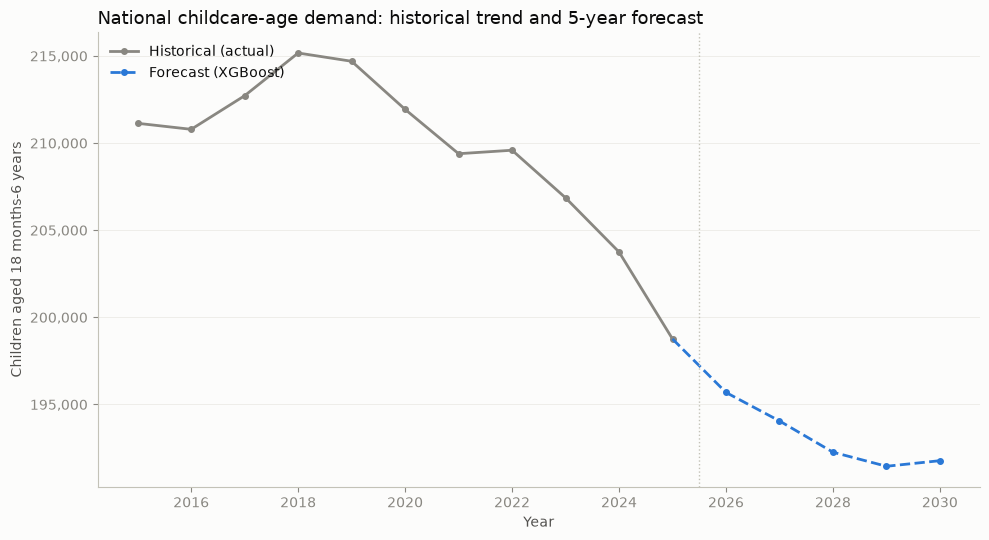

In [21]:
HIST_START_YEAR = 2015

hist_national = (
    demand_hist[demand_hist["year"] >= HIST_START_YEAR]
    .groupby("year", as_index=False)["children_18m_to_6"].sum()
    .rename(columns={"children_18m_to_6": "demand"})
)
fc_national = (
    forecast_selected.groupby("year", as_index=False)["forecast_demand_children"].sum()
    .rename(columns={"forecast_demand_children": "demand"})
    .sort_values("year")
)

fig, ax = plt.subplots(figsize=(10, 5.5))
ax.plot(hist_national["year"], hist_national["demand"], color=COLOR_HIST, linewidth=2,
        marker="o", markersize=4, label="Historical (actual)")

bridge_years = [hist_national["year"].max(), fc_national["year"].min()]
bridge_vals = [hist_national["demand"].iloc[-1], fc_national["demand"].iloc[0]]
ax.plot(bridge_years, bridge_vals, color=COLOR_FORECAST, linewidth=2, linestyle="--")
ax.plot(fc_national["year"], fc_national["demand"], color=COLOR_FORECAST, linewidth=2,
        linestyle="--", marker="o", markersize=4, label=f"Forecast ({best_model})")

ax.axvline(hist_national["year"].max() + 0.5, color="#c3c2b7", linewidth=1, linestyle=":")
ax.set_title("National childcare-age demand: historical trend and 5-year forecast",
             fontsize=13, loc="left")
ax.set_ylabel("Children aged 18 months-6 years")
ax.set_xlabel("Year")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:,.0f}"))
ax.legend(frameon=False, loc="upper left")
ax.grid(axis="y", alpha=0.6)
ax.grid(axis="x", visible=False)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "06_demand_trend_national.png", dpi=200)
plt.show()

In [ ]:
TOP_N_AREAS = 20

pa_year = (
    forecast_selected.groupby(["planning_area_clean", "year"], as_index=False)
                     ["forecast_demand_children"].sum()
)
pivot = pa_year.pivot(index="planning_area_clean", columns="year", values="forecast_demand_children").fillna(0)
pivot = pivot.loc[pivot.sum(axis=1).sort_values(ascending=False).index].head(TOP_N_AREAS)

fig, ax = plt.subplots(figsize=(8, 9))
im = ax.imshow(pivot.values, cmap=ORANGE_CMAP, aspect="auto")
ax.set_xticks(range(len(pivot.columns)))
ax.set_xticklabels(pivot.columns)
ax.set_yticks(range(len(pivot.index)))
ax.set_yticklabels([s.title() for s in pivot.index])
ax.set_title(f"Forecast childcare-age demand by planning area (top {TOP_N_AREAS})",
             fontsize=13, loc="left")
for spine in ax.spines.values():
    spine.set_visible(False)
ax.tick_params(length=0)
cbar = fig.colorbar(im, ax=ax, fraction=0.04, pad=0.02)
cbar.set_label("Forecast demand (children)")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "07_demand_heatmap_planning_area.png", dpi=200)
plt.show()

In [ ]:
top_bar = (
    gap_sorted[gap_sorted["year"] == FOCUS_YEAR]
    .sort_values("additional_centres_needed", ascending=False)
    .head(15)
    .iloc[::-1]
)
labels = top_bar["planning_area_clean"].str.title() + " - " + top_bar["subzone_clean"].str.title()

fig, ax = plt.subplots(figsize=(9, 7))
ax.barh(labels, top_bar["additional_centres_needed"], color=COLOR_BAR, height=0.6)
for y, v in enumerate(top_bar["additional_centres_needed"]):
    ax.text(v + 0.3, y, f"{int(v)}", va="center", fontsize=9, color="#0b0b0b")

ax.set_xlabel("Additional centres needed")
ax.set_title(f"Top 15 priority subzones, {FOCUS_YEAR}", fontsize=13, loc="left")
ax.grid(axis="x", alpha=0.6)
ax.grid(axis="y", visible=False)
for spine in ["top", "right", "left"]:
    ax.spines[spine].set_visible(False)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "08_top_priority_subzones_bar.png", dpi=200)
plt.show()

In [ ]:
map_data = subzone_gdf.merge(
    gap_sorted[gap_sorted["year"] == FOCUS_YEAR][
        ["planning_area_clean", "subzone_clean", "shortfall_children", "additional_centres_needed"]
    ],
    on=["planning_area_clean", "subzone_clean"],
    how="left"
)

fig, ax = plt.subplots(figsize=(8, 9))
map_data.plot(
    column="additional_centres_needed",
    cmap=ORANGE_CMAP,
    linewidth=0.2,
    edgecolor="#c3c2b7",
    legend=True,
    ax=ax,
    missing_kwds={
        "color": "#f0efec",
        "edgecolor": "#c3c2b7",
        "linewidth": 0.2,
        "label": "No forecast (non-residential / excluded)",
    },
    legend_kwds={"label": "Additional centres needed", "shrink": 0.6},
)
ax.set_axis_off()
ax.set_title(f"Where the shortage is: additional centres needed by subzone, {FOCUS_YEAR}",
             fontsize=13, loc="left")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "09_shortfall_map_singapore.png", dpi=200)
plt.show()

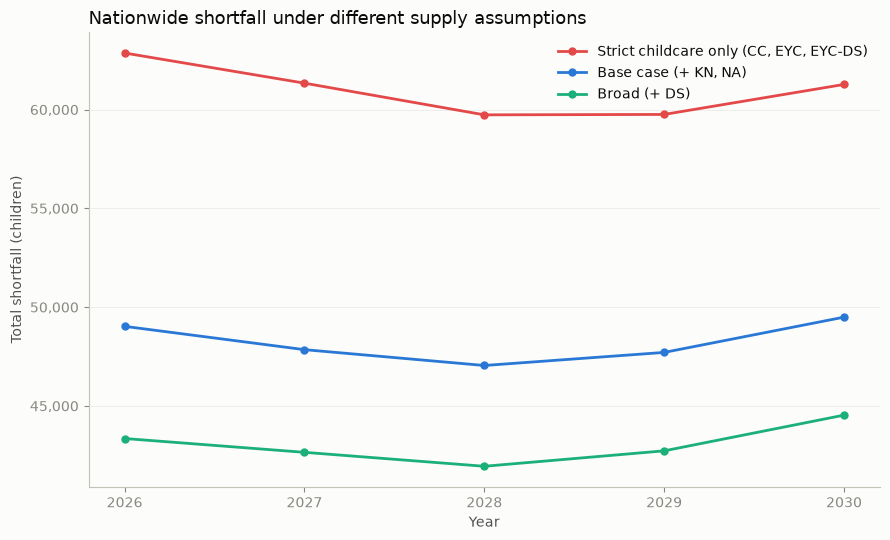

In [25]:
fig, ax = plt.subplots(figsize=(9, 5.5))
for scenario in ["strict_childcare", "base_preschool", "broad_all"]:
    d = scenario_summary[scenario_summary["supply_scenario"] == scenario].sort_values("year")
    ax.plot(d["year"], d["total_shortfall_children"], marker="o", markersize=5, linewidth=2,
            color=SCENARIO_COLORS[scenario], label=SCENARIO_LABELS[scenario])

ax.set_title("Nationwide shortfall under different supply assumptions", fontsize=13, loc="left")
ax.set_xlabel("Year")
ax.set_ylabel("Total shortfall (children)")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:,.0f}"))
ax.set_xticks(sorted(scenario_summary["year"].unique()))
ax.legend(frameon=False, loc="upper right")
ax.grid(axis="y", alpha=0.6)
ax.grid(axis="x", visible=False)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "10_scenario_sensitivity_line.png", dpi=200)
plt.show()